<a href="https://www.kaggle.com/code/omborse771924/bank-transaction-fraud-detection-dataset-eda?scriptVersionId=326928470" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nafiulislam490/bank-transaction-fraud-detection-dataset/bank_fraud.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nafiulislam490/bank-transaction-fraud-detection-dataset/bank_fraud.csv')

In [3]:
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [4]:
df.tail()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
999995,TXN0000999996,CUST00176672,2022-11-18,21:15:00,21,0,0,Mexico,Lyon,Electronics,...,1923.52,145,20,36.5,1.58,0,0,0,0,NaN
999996,TXN0000999997,CUST00005742,2021-07-03,22:57:00,22,1,1,Mexico,Tokyo,Online Shopping,...,146.16,154,17,20.0,2.10,0,0,0,0,NaN
999997,TXN0000999998,CUST00108137,2021-08-12,07:37:00,7,0,0,USA,Manchester,Grocery,...,27.38,148,20,3.4,2.74,0,1,0,0,NaN
999998,TXN0000999999,CUST00117141,2021-06-07,07:09:00,7,0,0,Japan,São Paulo,Electronics,...,365.30,150,16,63.1,3.71,1,1,0,0,NaN
999999,TXN0001000000,CUST00117401,2021-01-07,18:43:00,18,0,0,India,Berlin,Crypto Exchange,...,60.82,154,15,12.6,13.53,1,0,0,0,NaN


In [5]:
df.describe

<bound method NDFrame.describe of        transaction_id   customer_id transaction_date transaction_time  \
0       TXN0000000001  CUST00121959       2023-08-17         21:13:00   
1       TXN0000000002  CUST00146868       2024-02-06         05:16:00   
2       TXN0000000003  CUST00131933       2024-06-28         12:15:00   
3       TXN0000000004  CUST00103695       2023-03-16         02:53:00   
4       TXN0000000005  CUST00119880       2024-07-12         12:39:00   
...               ...           ...              ...              ...   
999995  TXN0000999996  CUST00176672       2022-11-18         21:15:00   
999996  TXN0000999997  CUST00005742       2021-07-03         22:57:00   
999997  TXN0000999998  CUST00108137       2021-08-12         07:37:00   
999998  TXN0000999999  CUST00117141       2021-06-07         07:09:00   
999999  TXN0001000000  CUST00117401       2021-01-07         18:43:00   

        hour_of_day  is_weekend  is_night_transaction country        city  \
0           

In [6]:
df.isnull()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
999996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
999997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
999998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [7]:
df.isnull().sum()

transaction_id                   0
customer_id                      0
transaction_date                 0
transaction_time                 0
hour_of_day                      0
is_weekend                       0
is_night_transaction             0
country                          0
city                             0
merchant_category                0
payment_method                   0
device_type                      0
customer_age                     0
credit_score                     0
account_age_years                0
account_balance                  0
transaction_amount               0
num_prev_transactions            0
transaction_freq_monthly         0
distance_from_home_km            0
time_since_last_txn_hrs          0
is_international                 0
failed_attempts                  0
pin_changed_recently             0
is_fraud                         0
fraud_type                  944745
dtype: int64

In [8]:
# Check before

print("Before Handling Missing Values")

print(
    df.isnull().sum()
)





# ============================================================
# HANDLE FRAUD TYPE
# ============================================================

df["fraud_type"] = df["fraud_type"].fillna(
    "No Fraud"
)






# ============================================================
# VERIFY NULL VALUES
# ============================================================

print("\nAfter Handling Missing Values")


print(
    df.isnull().sum()
)




print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)





# ============================================================
# CHECK FRAUD TYPE DISTRIBUTION
# ============================================================


print(
    df["fraud_type"].value_counts()
)

Before Handling Missing Values
transaction_id                   0
customer_id                      0
transaction_date                 0
transaction_time                 0
hour_of_day                      0
is_weekend                       0
is_night_transaction             0
country                          0
city                             0
merchant_category                0
payment_method                   0
device_type                      0
customer_age                     0
credit_score                     0
account_age_years                0
account_balance                  0
transaction_amount               0
num_prev_transactions            0
transaction_freq_monthly         0
distance_from_home_km            0
time_since_last_txn_hrs          0
is_international                 0
failed_attempts                  0
pin_changed_recently             0
is_fraud                         0
fraud_type                  944745
dtype: int64

After Handling Missing Values
transaction_id 

In [9]:
df.isnull()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
999996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
999997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
999998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

transaction_id              0
customer_id                 0
transaction_date            0
transaction_time            0
hour_of_day                 0
is_weekend                  0
is_night_transaction        0
country                     0
city                        0
merchant_category           0
payment_method              0
device_type                 0
customer_age                0
credit_score                0
account_age_years           0
account_balance             0
transaction_amount          0
num_prev_transactions       0
transaction_freq_monthly    0
distance_from_home_km       0
time_since_last_txn_hrs     0
is_international            0
failed_attempts             0
pin_changed_recently        0
is_fraud                    0
fraud_type                  0
dtype: int64

In [11]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 1000000, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type'],
      dtype='object')

## EDA

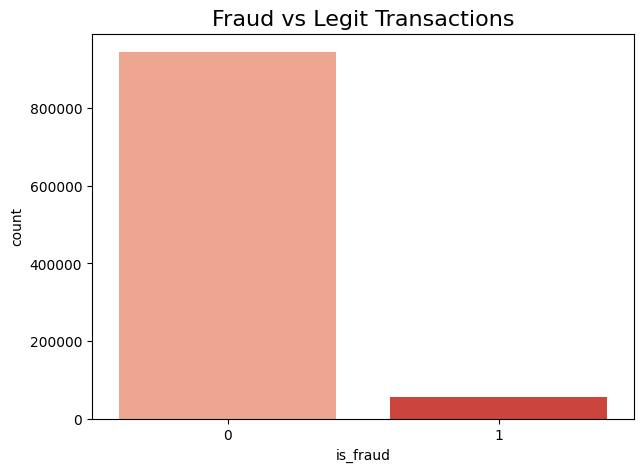

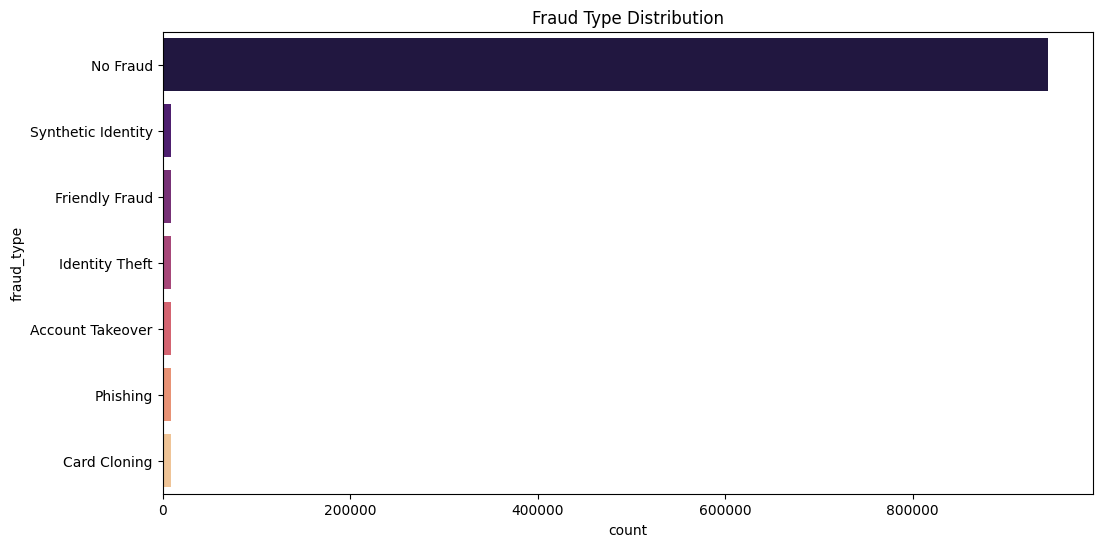

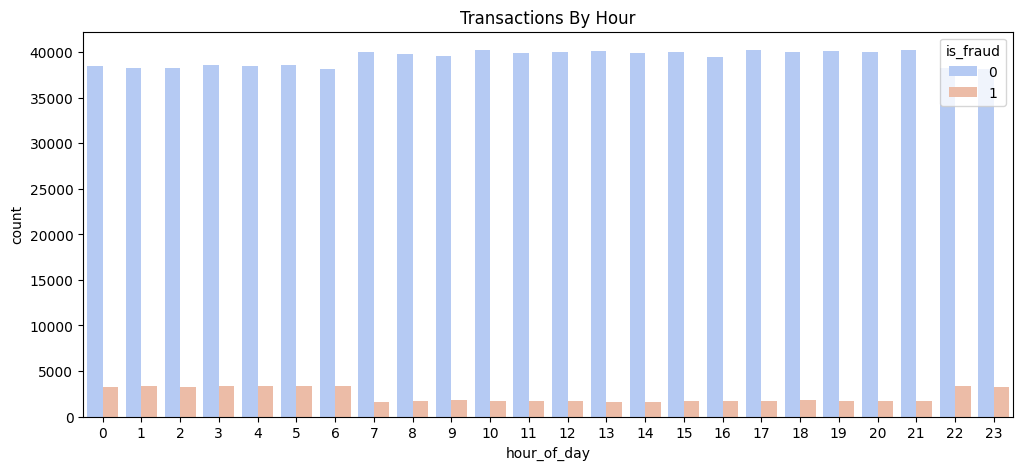

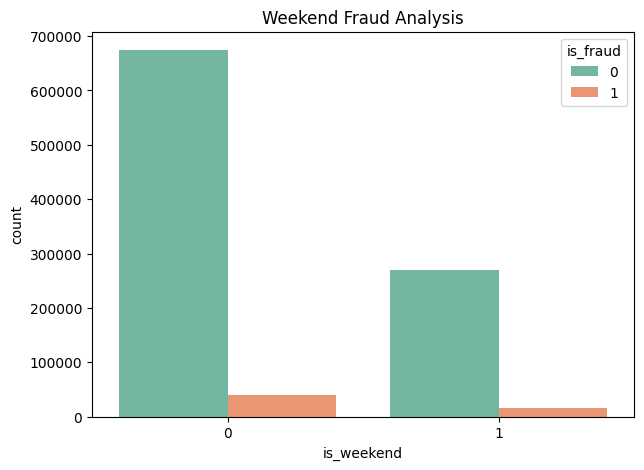

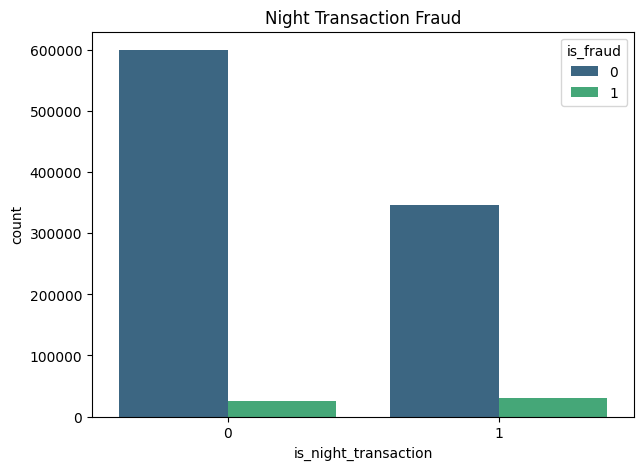

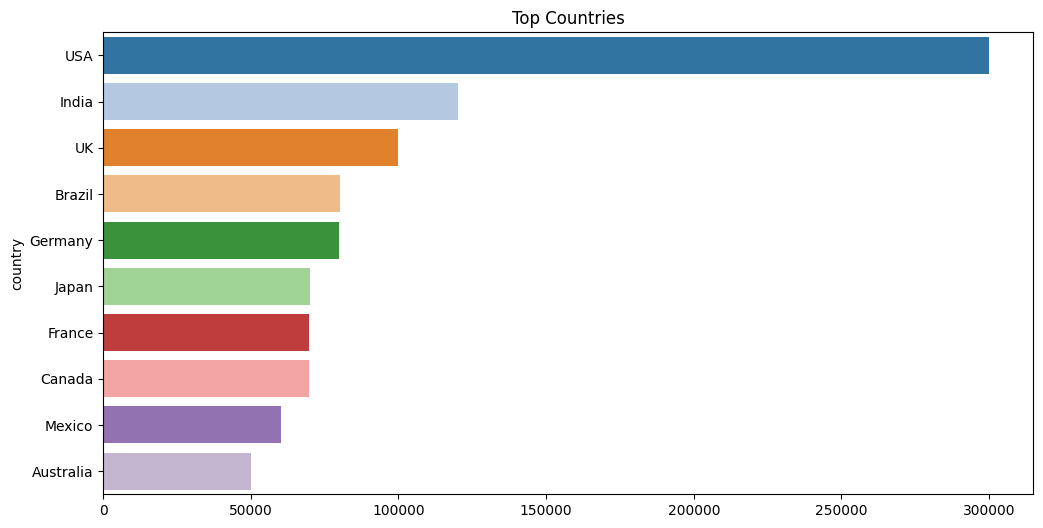

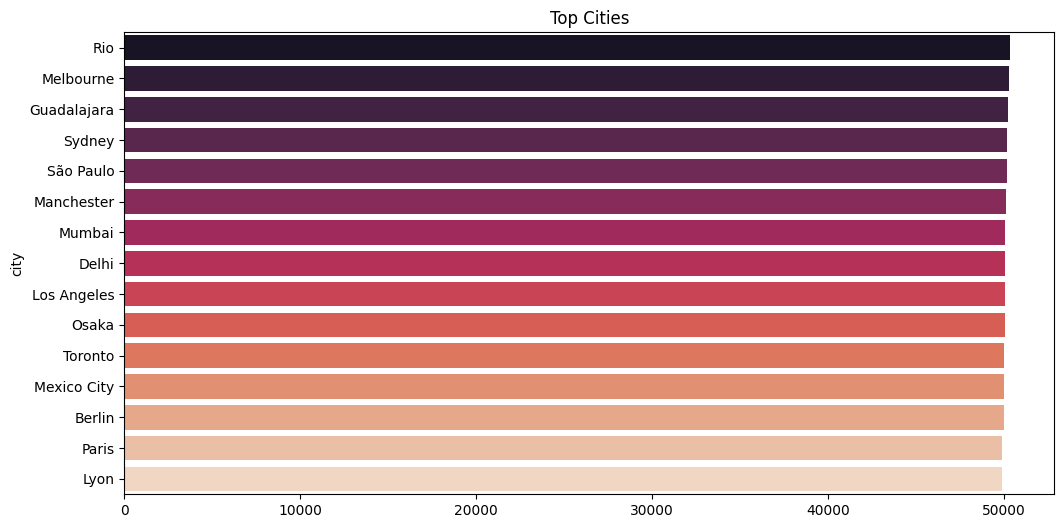

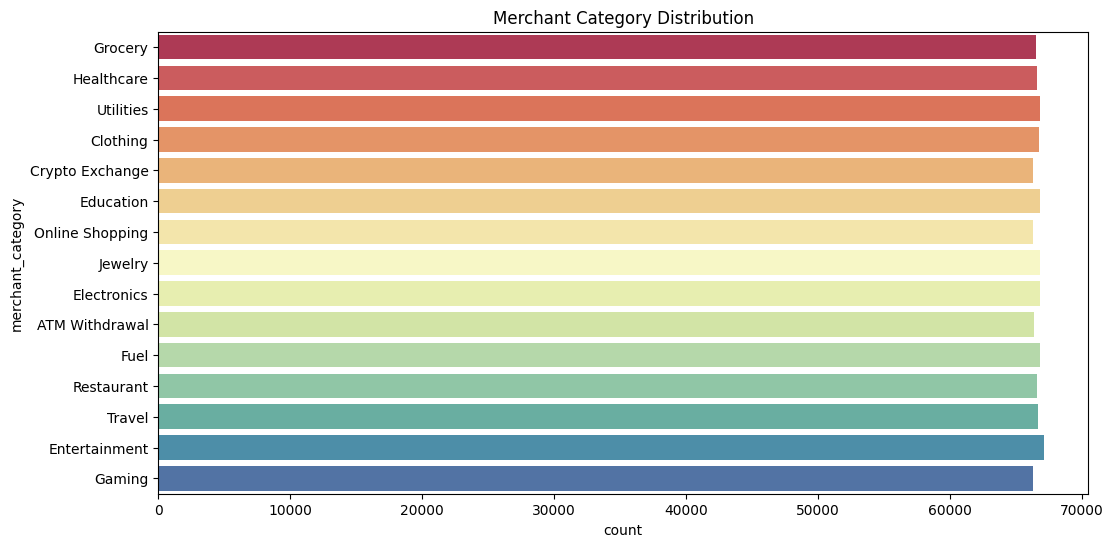

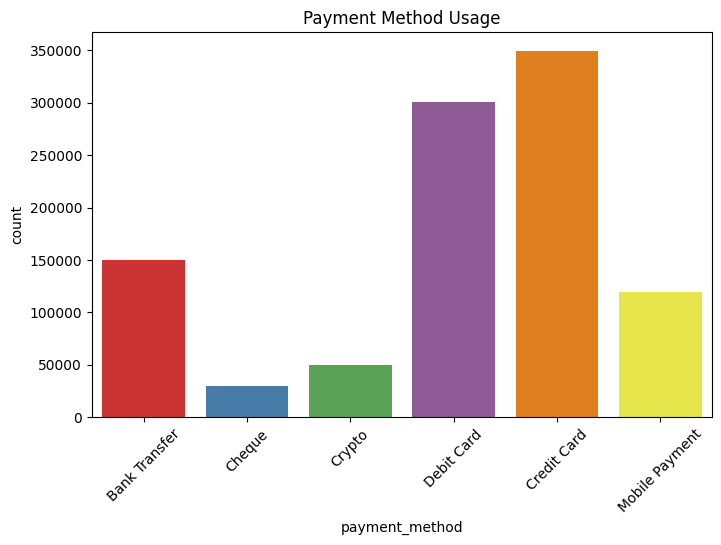

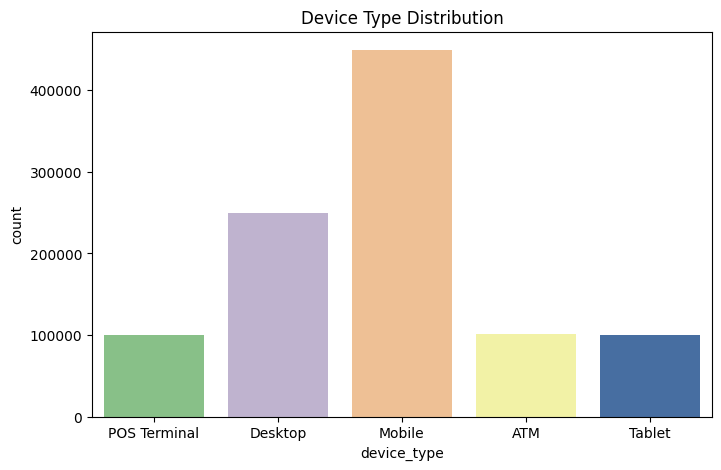

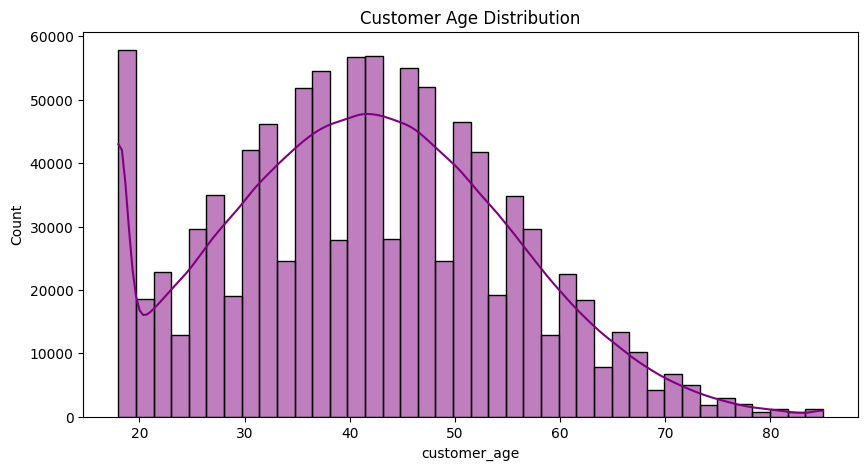

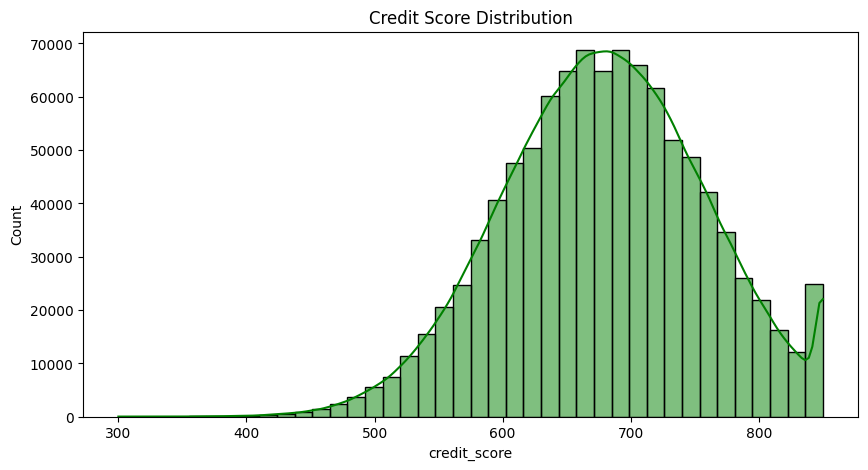

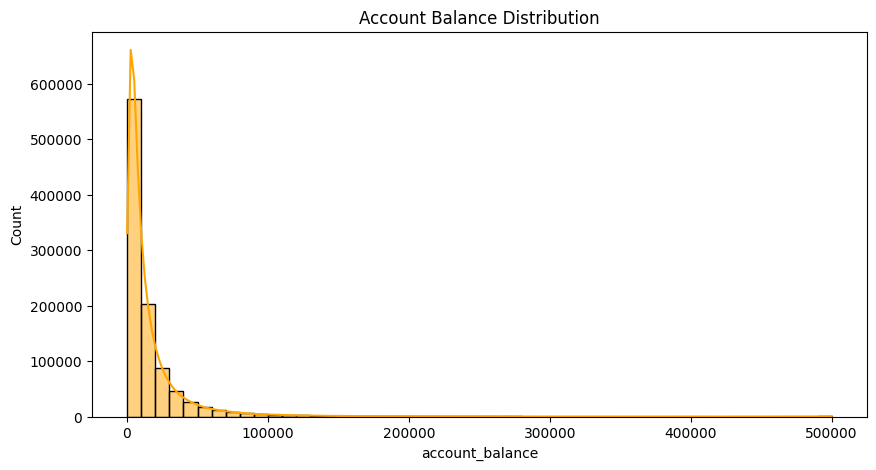

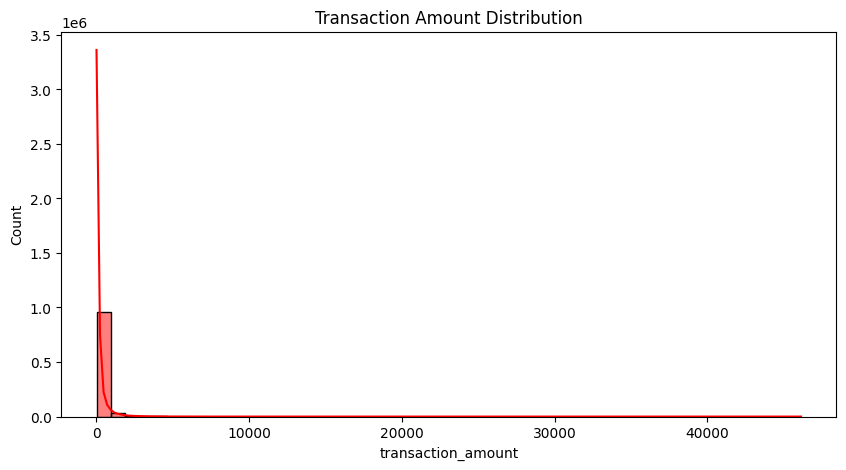

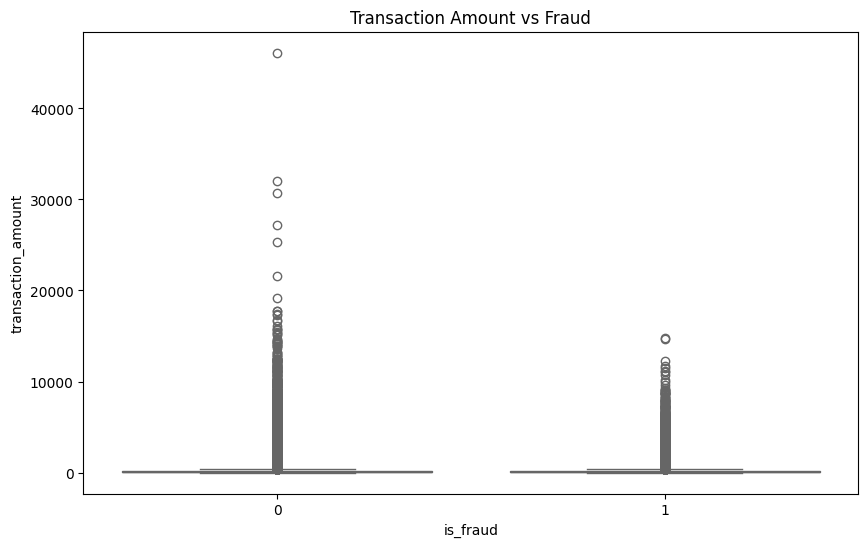

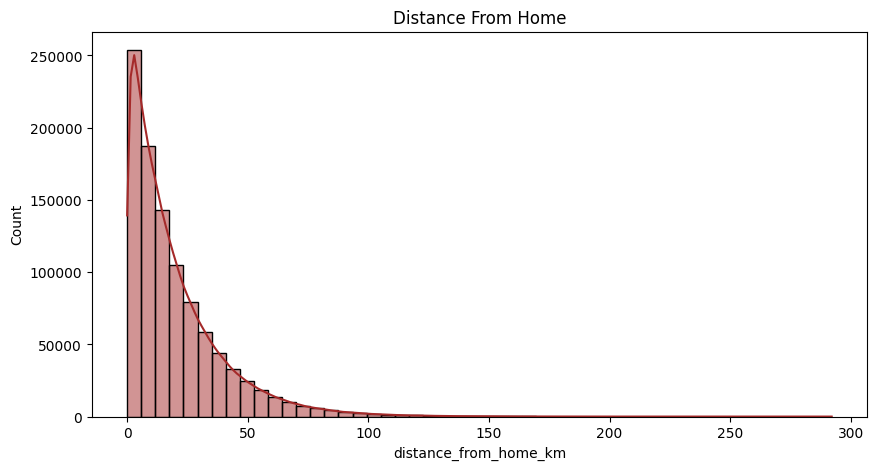

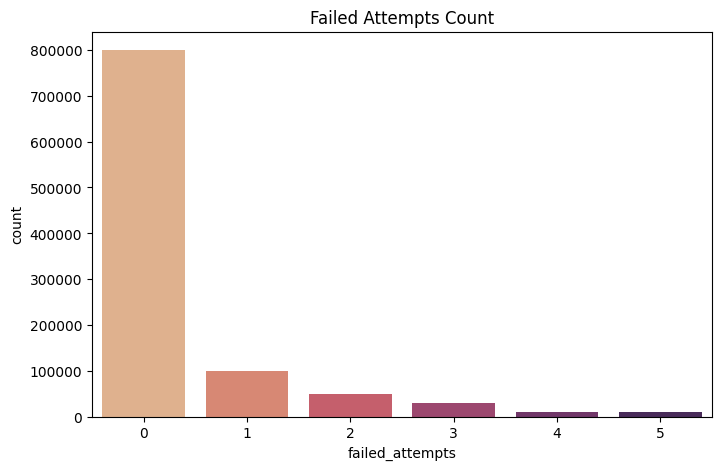

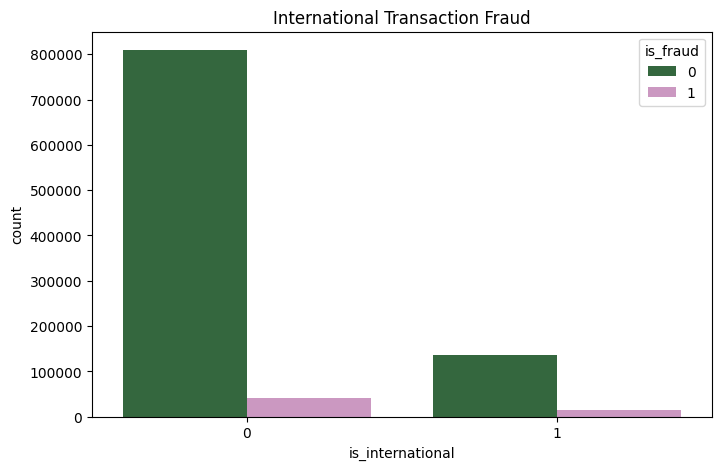

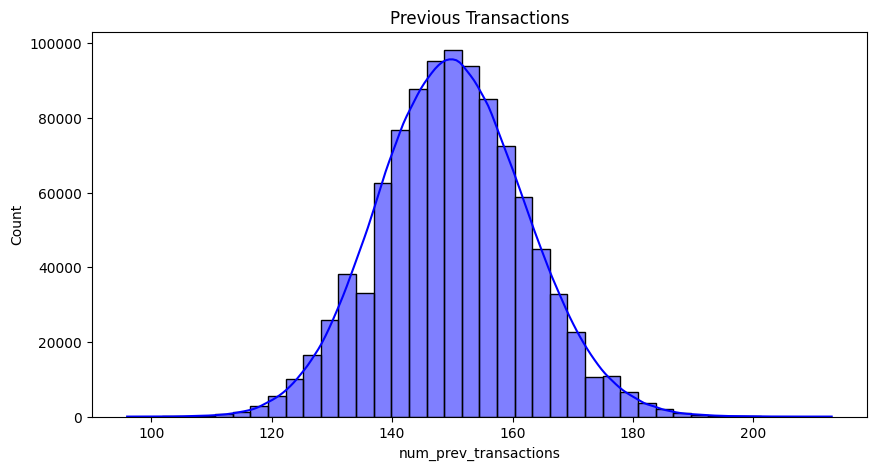

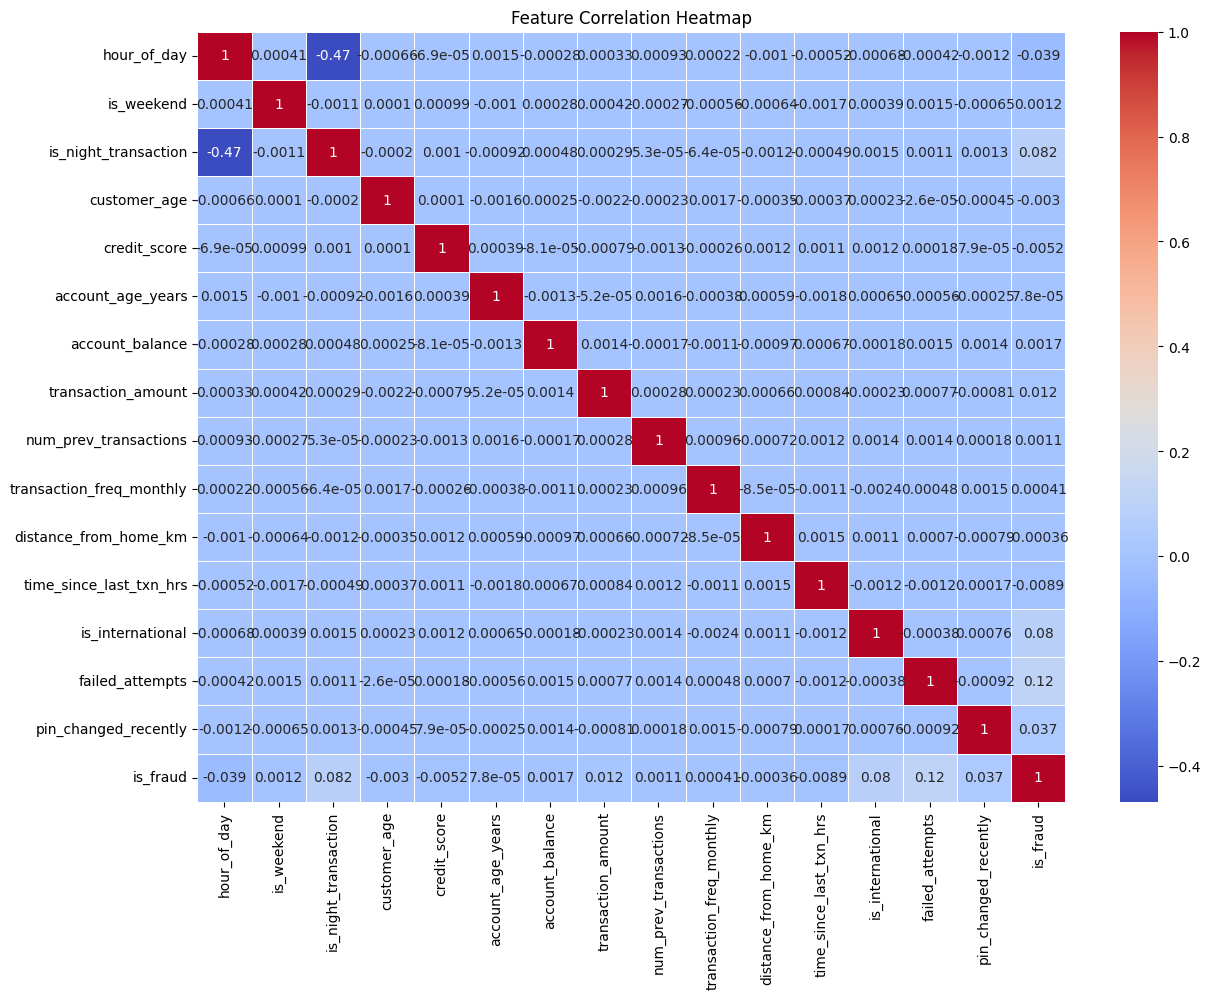

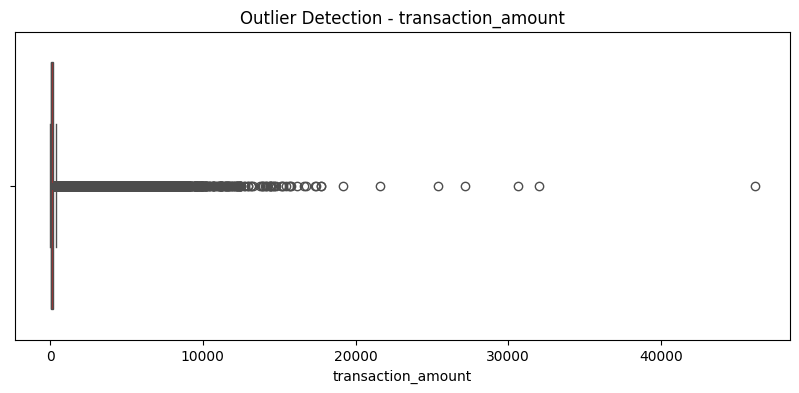

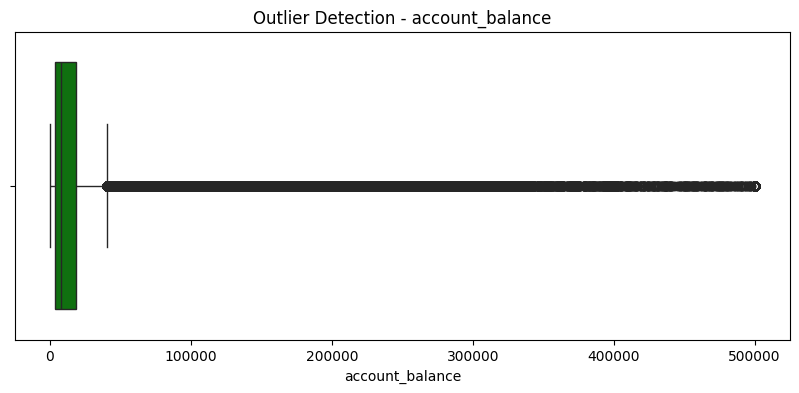

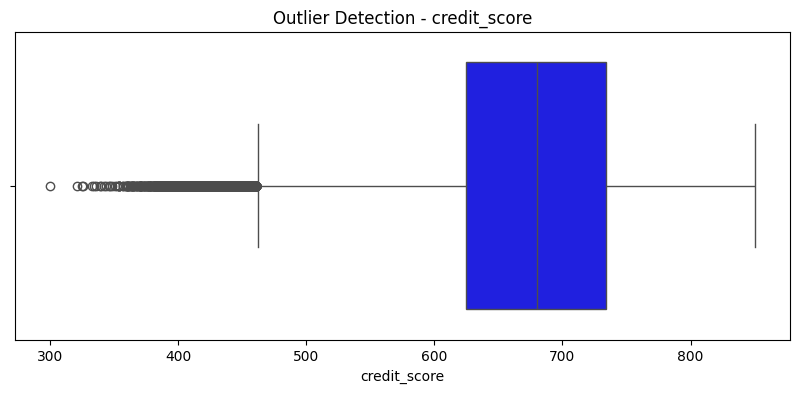

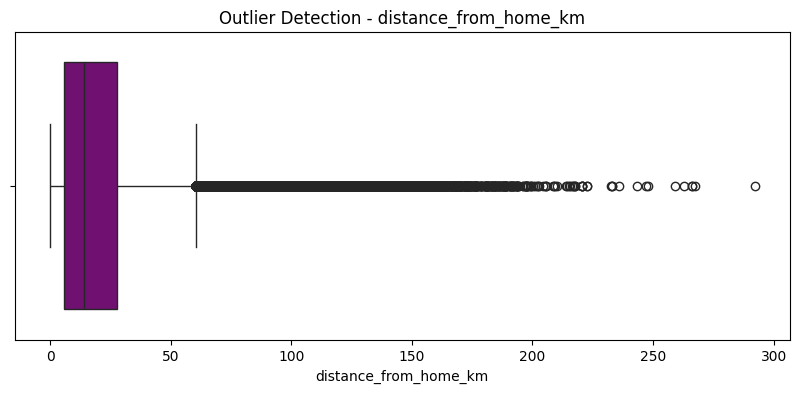

Fraud Transaction Visualization Completed Successfully!


In [14]:
# ============================================================
# 1. FRAUD DISTRIBUTION
# ============================================================

plt.figure(figsize=(7,5))


sns.countplot(

    data=df,

    x="is_fraud",

    hue="is_fraud",

    palette="Reds",

    legend=False

)


plt.title(
    "Fraud vs Legit Transactions",
    fontsize=16
)


plt.show()







# ============================================================
# 2. FRAUD TYPE
# ============================================================


plt.figure(figsize=(12,6))


sns.countplot(

    data=df,

    y="fraud_type",

    hue="fraud_type",

    palette="magma",

    legend=False

)


plt.title(
    "Fraud Type Distribution"
)


plt.show()








# ============================================================
# 3. TRANSACTION BY HOUR
# ============================================================


plt.figure(figsize=(12,5))


sns.countplot(

    data=df,

    x="hour_of_day",

    hue="is_fraud",

    palette="coolwarm"

)


plt.title(
    "Transactions By Hour"
)


plt.show()








# ============================================================
# 4. WEEKEND TRANSACTIONS
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

    data=df,

    x="is_weekend",

    hue="is_fraud",

    palette="Set2"

)


plt.title(
    "Weekend Fraud Analysis"
)


plt.show()








# ============================================================
# 5. NIGHT TRANSACTION
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

    data=df,

    x="is_night_transaction",

    hue="is_fraud",

    palette="viridis"

)


plt.title(
    "Night Transaction Fraud"
)


plt.show()









# ============================================================
# 6. TOP COUNTRIES
# ============================================================


country=df["country"].value_counts().head(15)


plt.figure(figsize=(12,6))


sns.barplot(

    x=country.values,

    y=country.index,

    hue=country.index,

    palette="tab20",

    legend=False

)



plt.title(
    "Top Countries"
)


plt.show()









# ============================================================
# 7. TOP CITIES
# ============================================================


city=df["city"].value_counts().head(15)


plt.figure(figsize=(12,6))


sns.barplot(

    x=city.values,

    y=city.index,

    hue=city.index,

    palette="rocket",

    legend=False

)


plt.title(
    "Top Cities"
)


plt.show()









# ============================================================
# 8. MERCHANT CATEGORY
# ============================================================


plt.figure(figsize=(12,6))


sns.countplot(

    data=df,

    y="merchant_category",

    hue="merchant_category",

    palette="Spectral",

    legend=False

)



plt.title(
    "Merchant Category Distribution"
)



plt.show()








# ============================================================
# 9. PAYMENT METHOD
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

    data=df,

    x="payment_method",

    hue="payment_method",

    palette="Set1",

    legend=False

)



plt.title(
    "Payment Method Usage"
)


plt.xticks(rotation=45)


plt.show()







# ============================================================
# 10. DEVICE TYPE
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

    data=df,

    x="device_type",

    hue="device_type",

    palette="Accent",

    legend=False

)


plt.title(
    "Device Type Distribution"
)


plt.show()







# ============================================================
# 11. CUSTOMER AGE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["customer_age"],

    bins=40,

    kde=True,

    color="purple"

)



plt.title(
    "Customer Age Distribution"
)



plt.show()








# ============================================================
# 12. CREDIT SCORE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["credit_score"],

    bins=40,

    kde=True,

    color="green"

)



plt.title(
    "Credit Score Distribution"
)


plt.show()









# ============================================================
# 13. ACCOUNT BALANCE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["account_balance"],

    bins=50,

    kde=True,

    color="orange"

)


plt.title(
    "Account Balance Distribution"
)



plt.show()








# ============================================================
# 14. TRANSACTION AMOUNT
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["transaction_amount"],

    bins=50,

    kde=True,

    color="red"

)


plt.title(
    "Transaction Amount Distribution"
)


plt.show()








# ============================================================
# 15. AMOUNT VS FRAUD
# ============================================================


plt.figure(figsize=(10,6))


sns.boxplot(

    data=df,

    x="is_fraud",

    y="transaction_amount",

    hue="is_fraud",

    palette="cool",

    legend=False

)



plt.title(
    "Transaction Amount vs Fraud"
)



plt.show()








# ============================================================
# 16. DISTANCE FROM HOME
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["distance_from_home_km"],

    bins=50,

    kde=True,

    color="brown"

)


plt.title(
    "Distance From Home"
)


plt.show()








# ============================================================
# 17. FAILED ATTEMPTS
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

    data=df,

    x="failed_attempts",

    hue="failed_attempts",

    palette="flare",

    legend=False

)


plt.title(
    "Failed Attempts Count"
)


plt.show()








# ============================================================
# 18. INTERNATIONAL TRANSACTION
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

    data=df,

    x="is_international",

    hue="is_fraud",

    palette="cubehelix"

)



plt.title(
    "International Transaction Fraud"
)


plt.show()








# ============================================================
# 19. PREVIOUS TRANSACTIONS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["num_prev_transactions"],

    bins=40,

    kde=True,

    color="blue"

)



plt.title(
    "Previous Transactions"
)


plt.show()








# ============================================================
# 20. CORRELATION HEATMAP
# ============================================================


numeric_df=df.select_dtypes(
    include=np.number
)


plt.figure(figsize=(14,10))


sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap="coolwarm",

    linewidth=0.5

)


plt.title(
    "Feature Correlation Heatmap"
)


plt.show()








# ============================================================
# 21. OUTLIER DETECTION
# ============================================================


features=[

"transaction_amount",

"account_balance",

"credit_score",

"distance_from_home_km"

]



colors=[

"red",

"green",

"blue",

"purple"

]





for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )



    plt.title(
        f"Outlier Detection - {feature}"
    )


    plt.show()






print(
    "Fraud Transaction Visualization Completed Successfully!"
)

## Features Engineering

is_fraud
0    944745
1     55255
Name: count, dtype: int64

Logistic Regression
Accuracy: 0.7266
              precision    recall  f1-score   support

           0       0.96      0.74      0.84    188949
           1       0.11      0.54      0.18     11051

    accuracy                           0.73    200000
   macro avg       0.54      0.64      0.51    200000
weighted avg       0.92      0.73      0.80    200000


Decision Tree
Accuracy: 0.8954
              precision    recall  f1-score   support

           0       0.95      0.94      0.94    188949
           1       0.09      0.10      0.09     11051

    accuracy                           0.90    200000
   macro avg       0.52      0.52      0.52    200000
weighted avg       0.90      0.90      0.90    200000


Random Forest
Accuracy: 0.9447
              precision    recall  f1-score   support

           0       0.94      1.00      0.97    188949
           1       0.00      0.00      0.00     11051

    accuracy         

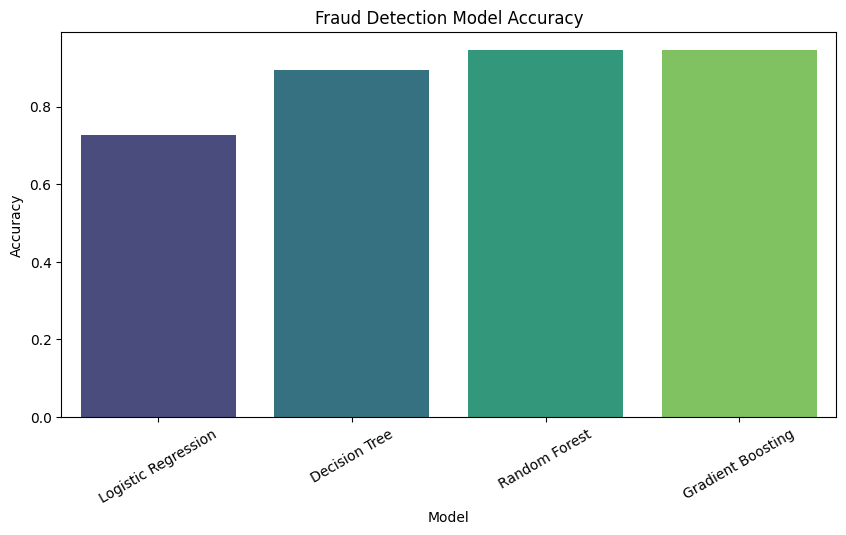

BEST MODEL: Random Forest


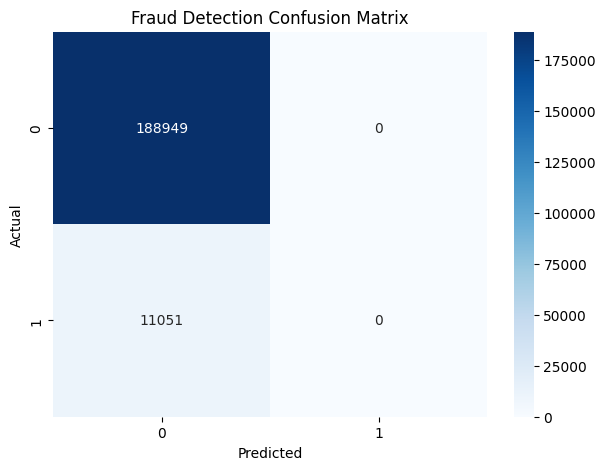

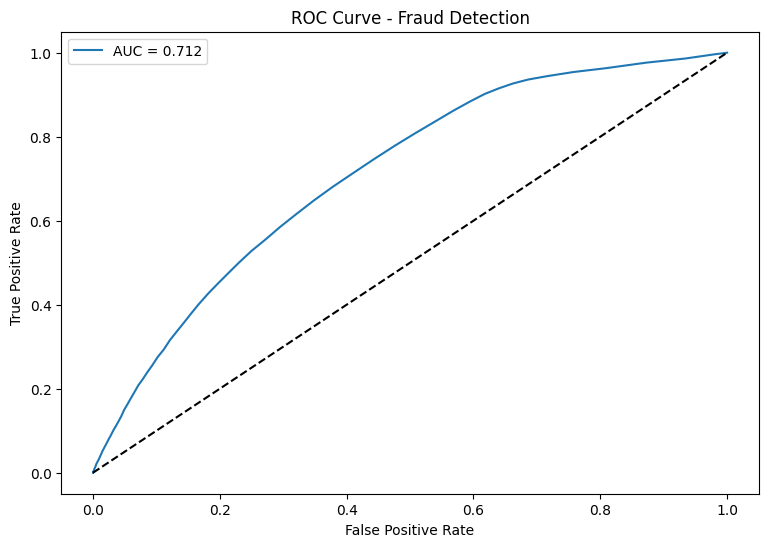

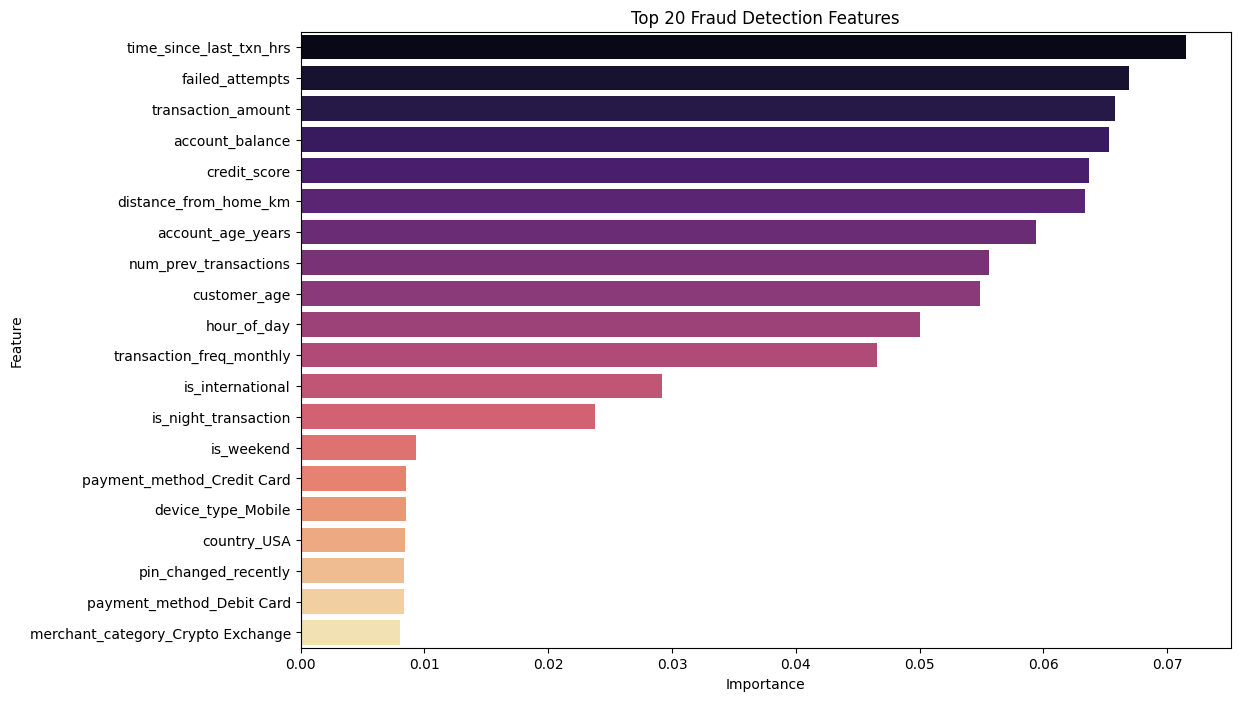


FINAL RESULTS
Logistic Regression : 0.7266
Decision Tree : 0.8954
Random Forest : 0.9447
Gradient Boosting : 0.9447
BEST MODEL: Random Forest
BEST ACCURACY: 0.9447


In [15]:
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer



from sklearn.linear_model import LogisticRegression


from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)



from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score

)







# ============================================================
# HANDLE NULL VALUES
# ============================================================

df["fraud_type"] = df["fraud_type"].fillna(
    "No Fraud"
)









# ============================================================
# TARGET
# ============================================================


target = "is_fraud"



X = df.drop(

    target,

    axis=1

)



y = df[target]



print(
    y.value_counts()
)










# ============================================================
# REMOVE DATA LEAKAGE COLUMNS
# ============================================================

# fraud_type directly tells fraud category
# transaction_id/customer_id are identifiers


leakage_cols=[


"transaction_id",

"customer_id",

"fraud_type",

"transaction_date",

"transaction_time"


]




for col in leakage_cols:


    if col in X.columns:


        X.drop(

            col,

            axis=1,

            inplace=True

        )










# ============================================================
# TRAIN TEST SPLIT
# BEFORE ENCODING
# ============================================================


X_train,X_test,y_train,y_test=train_test_split(


    X,


    y,


    test_size=0.2,


    random_state=42,


    stratify=y


)









# ============================================================
# NUMERIC AND CATEGORICAL COLUMNS
# ============================================================


numeric_cols = X.select_dtypes(

    include=np.number

).columns





categorical_cols = X.select_dtypes(

    include="object"

).columns











# ============================================================
# NUMERIC PIPELINE
# ============================================================


numeric_pipeline = Pipeline(

steps=[



(

"imputer",

SimpleImputer(

strategy="median"

)

),



(

"scaler",

StandardScaler()

)



]

)










# ============================================================
# CATEGORICAL PIPELINE
# ============================================================


categorical_pipeline = Pipeline(

steps=[



(

"imputer",

SimpleImputer(

strategy="most_frequent"

)

),




(

"encoder",

OneHotEncoder(

handle_unknown="ignore"

)

)



]

)









# ============================================================
# COLUMN TRANSFORMER
# ============================================================



preprocessor = ColumnTransformer(


transformers=[



(

"num",

numeric_pipeline,

numeric_cols

),




(

"cat",

categorical_pipeline,

categorical_cols

)



]


)









# ============================================================
# MODELS
# ============================================================



models={




"Logistic Regression":

LogisticRegression(

max_iter=1000,

class_weight="balanced"

),






"Decision Tree":

DecisionTreeClassifier(

random_state=42,

class_weight="balanced"

),







"Random Forest":

RandomForestClassifier(

n_estimators=300,

random_state=42,

class_weight="balanced"

),






"Gradient Boosting":

GradientBoostingClassifier(

random_state=42

)



}









results={}


trained_models={}









# ============================================================
# TRAINING
# ============================================================



for name,model in models.items():



    print("\n====================")

    print(name)

    print("====================")





    pipeline = Pipeline(

    steps=[




    (

    "preprocessing",

    preprocessor

    ),





    (

    "model",

    model

    )



    ]

    )







    pipeline.fit(

        X_train,

        y_train

    )








    prediction=pipeline.predict(

        X_test

    )









    acc=accuracy_score(

        y_test,

        prediction

    )









    results[name]=acc


    trained_models[name]=pipeline








    print(

        "Accuracy:",

        round(acc,4)

    )







    print(

        classification_report(

            y_test,

            prediction

        )

    )









# ============================================================
# MODEL ACCURACY COMPARISON
# ============================================================


accuracy_df=pd.DataFrame({

"Model":list(results.keys()),

"Accuracy":list(results.values())

})






plt.figure(figsize=(10,5))



sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)



plt.title(

"Fraud Detection Model Accuracy"

)



plt.xticks(rotation=30)



plt.show()










# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)




best_model=trained_models[

best_name

]






print(

"BEST MODEL:",

best_name

)










# ============================================================
# CONFUSION MATRIX
# ============================================================


best_pred = best_model.predict(

X_test

)






plt.figure(figsize=(7,5))



sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)





plt.title(

"Fraud Detection Confusion Matrix"

)



plt.xlabel(

"Predicted"

)


plt.ylabel(

"Actual"

)



plt.show()










# ============================================================
# ROC CURVE
# ============================================================



prob = best_model.predict_proba(

X_test

)[:,1]






fpr,tpr,_ = roc_curve(

y_test,

prob

)






auc = roc_auc_score(

y_test,

prob

)






plt.figure(figsize=(9,6))




plt.plot(

fpr,

tpr,

label=f"AUC = {auc:.3f}"

)





plt.plot(

[0,1],

[0,1],

"k--"

)




plt.xlabel(

"False Positive Rate"

)



plt.ylabel(

"True Positive Rate"

)



plt.title(

"ROC Curve - Fraud Detection"

)



plt.legend()



plt.show()









# ============================================================
# FEATURE IMPORTANCE
# ============================================================


rf = trained_models[

"Random Forest"

]





feature_names=(


list(numeric_cols)


+


list(

rf.named_steps["preprocessing"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(

categorical_cols

)

)


)






importance=pd.DataFrame({

"Feature":feature_names,


"Importance":

rf.named_steps["model"]

.feature_importances_


})







importance=importance.sort_values(

"Importance",

ascending=False

)






plt.figure(figsize=(12,8))



sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)





plt.title(

"Top 20 Fraud Detection Features"

)




plt.show()










# ============================================================
# FINAL RESULT
# ============================================================


print("\nFINAL RESULTS")

print("====================")



for model,score in results.items():


    print(

        model,

        ":",

        round(score,4)

    )





print("====================")


print(

"BEST MODEL:",

best_name

)



print(

"BEST ACCURACY:",

round(max(results.values()),4)

)